<a href="https://colab.research.google.com/github/MukRodrigues/Projetos-Python/blob/main/SRAG-Brasil-2019-2026/SRAG_curvas_epidemicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SRAG 2019 - 2026

## Dataset

In [8]:
import json
import re
from urllib.request import urlopen
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [9]:
# ============================================================
# 1. Endereço raw do arquivo no GitLab
# https://gitlab.com/cgcovid/dados-publicos
# ============================================================
# dados inicialmente baixados do gitlab em 15/09/2026 às 16:27
url = (
    "https://gitlab.com/cgcovid/dados-publicos/-/raw/main/"
    "S%C3%A9ries%20hist%C3%B3ricas/Srag/Brasil/"
    "serie_historica_casos.html"
)


# ============================================================
# 2. Download do arquivo HTML
# ============================================================

with urlopen(url) as resposta:
    html = resposta.read().decode("utf-8")


# ============================================================
# 3. Localização do JSON utilizado pelo Plotly
# ============================================================

padrao = re.compile(
    r'<script[^>]*type=["\']application/json["\'][^>]*>'
    r'(.*?)'
    r'</script>',
    flags=re.DOTALL
)

blocos_json = padrao.findall(html)

if not blocos_json:
    raise ValueError(
        "Nenhum bloco JSON foi encontrado no arquivo HTML."
    )


# ============================================================
# 4. Identificação do bloco que contém os dados do gráfico
# ============================================================

dados_plotly = None

for bloco in blocos_json:
    objeto = json.loads(bloco)

    if (
        isinstance(objeto, dict)
        and "x" in objeto
        and "data" in objeto["x"]
    ):
        dados_plotly = objeto["x"]["data"]
        break

if dados_plotly is None:
    raise ValueError(
        "O JSON foi encontrado, mas os dados do Plotly não foram localizados."
    )


# ============================================================
# 5. Transformação dos dados em registros tabulares
# ============================================================

registros = []

for serie in dados_plotly:

    nome_virus = serie["name"]
    indices_temporais = serie["x"]
    numero_casos = serie["y"]

    for indice, casos in zip(indices_temporais, numero_casos):

        registros.append({
            "indice_temporal": indice,
            "virus": nome_virus,
            "casos": casos
        })


# ============================================================
# 6. Criação do DataFrame
# ============================================================

df = pd.DataFrame(registros)


# ============================================================
# 7. Conversão dos tipos
# ============================================================

df["indice_temporal"] = pd.to_numeric(
    df["indice_temporal"],
    errors="coerce"
).astype("Int64")

df["casos"] = pd.to_numeric(
    df["casos"],
    errors="coerce"
)


# ============================================================
# 8. Recuperação do ano e da semana epidemiológica
# ============================================================

df["ano"] = (
    2019 + (df["indice_temporal"] - 1) // 53
).astype("Int64")

df["semana"] = (
    1 + (df["indice_temporal"] - 1) % 53
).astype("Int64")


# Identificação no formato ano-SE
df["ano_semana"] = (
    df["ano"].astype(str)
    + "-SE"
    + df["semana"].astype(str).str.zfill(2)
)


# ============================================================
# 9. Ordenação cronológica
# ============================================================

df = df.sort_values(
    ["indice_temporal", "virus"]
).reset_index(drop=True)


# ============================================================
# 10. Visualização inicial
# ============================================================

print(df.head())
print()
print(df.info())

   indice_temporal                       virus  casos   ano  semana ano_semana
0                1                  Adenovírus      6  2019       1  2019-SE01
1                1                   Bocavírus      0  2019       1  2019-SE01
2                1      Influenza A(H1N1)pdm09      7  2019       1  2019-SE01
3                1           Influenza A(H3N2)      1  2019       1  2019-SE01
4                1  Influenza A(não subtipada)      2  2019       1  2019-SE01

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   indice_temporal  4800 non-null   Int64 
 1   virus            4800 non-null   object
 2   casos            4800 non-null   int64 
 3   ano              4800 non-null   Int64 
 4   semana           4800 non-null   Int64 
 5   ano_semana       4800 non-null   object
dtypes: Int64(3), int64(1), object(2)
memory usage: 239.2+ 

In [10]:
df.to_csv('dados_SRAG_gitlab_15092026.csv', index=False)

In [11]:
df['casos'].describe()

,casos
count,4800.000000
mean,373.136667
std,2214.655787
min,0.000000
25%,6.000000
50%,24.000000
75%,93.000000
max,40358.000000


## Semanas Epidemiológicas

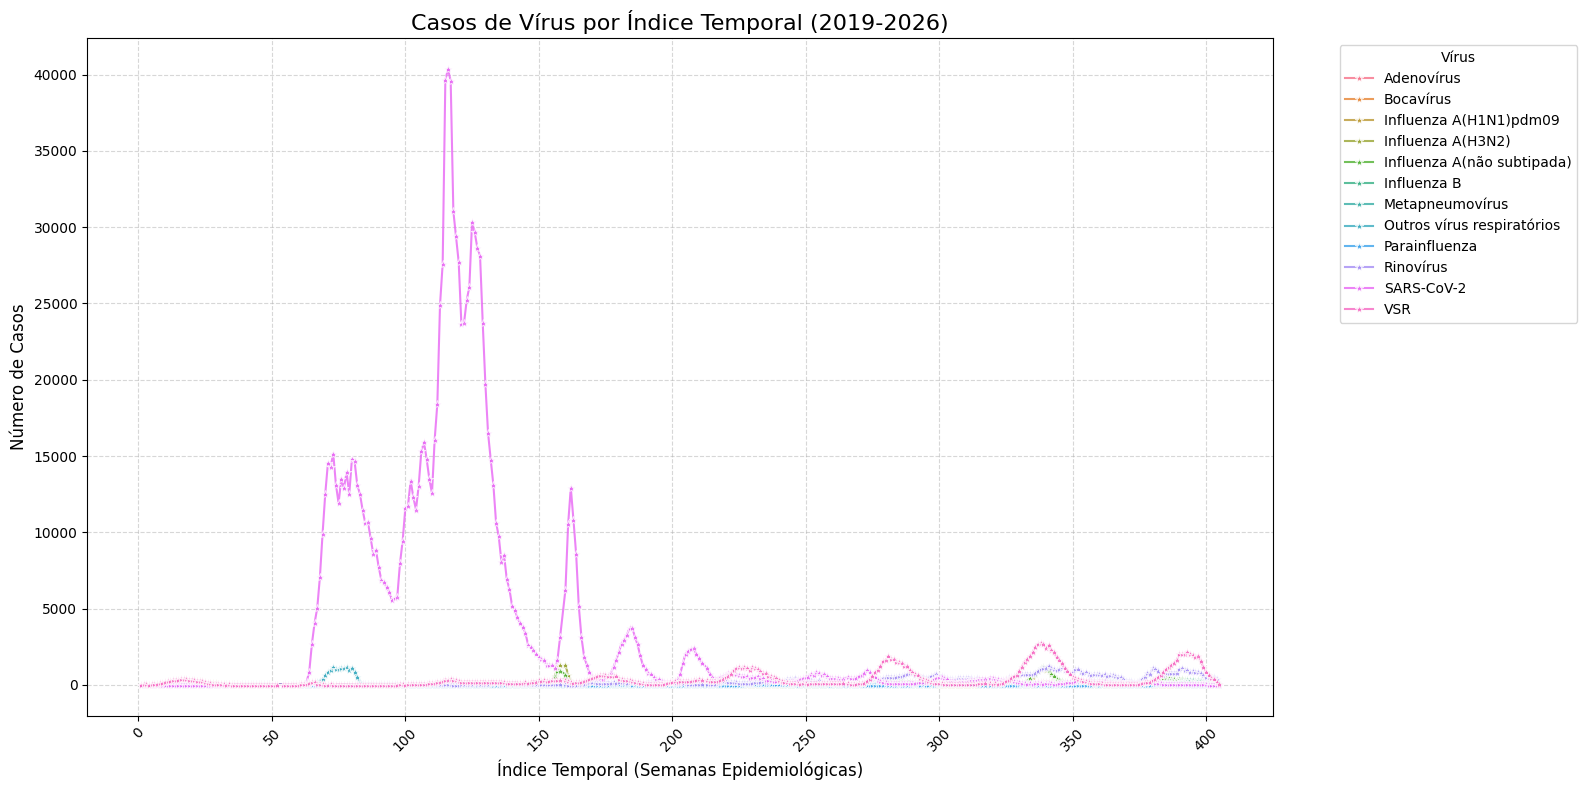

In [12]:
df_filtered = df[(df['ano'] >= 2019) & (df['ano'] <= 2026) ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title('Casos de Vírus por Índice Temporal (2019-2026)', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Curvas Epidêmicas de 2019 a 2025

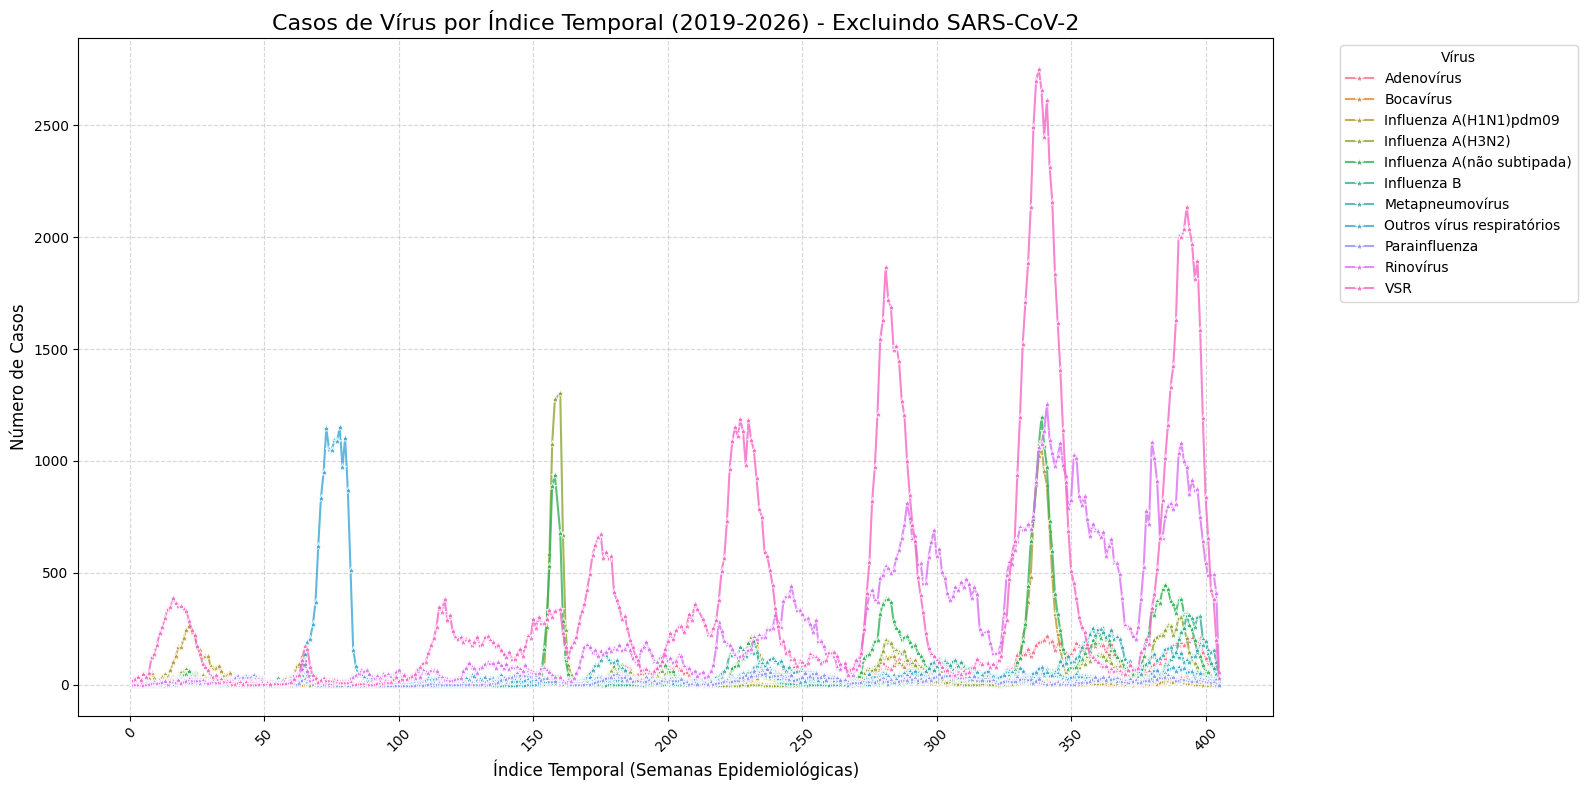

In [13]:
df_filtered = df[(df['ano'] >= 2019) & (df['ano'] <= 2026) & (df['virus'] != "SARS-CoV-2")  ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title('Casos de Vírus por Índice Temporal (2019-2026) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Ano a ano

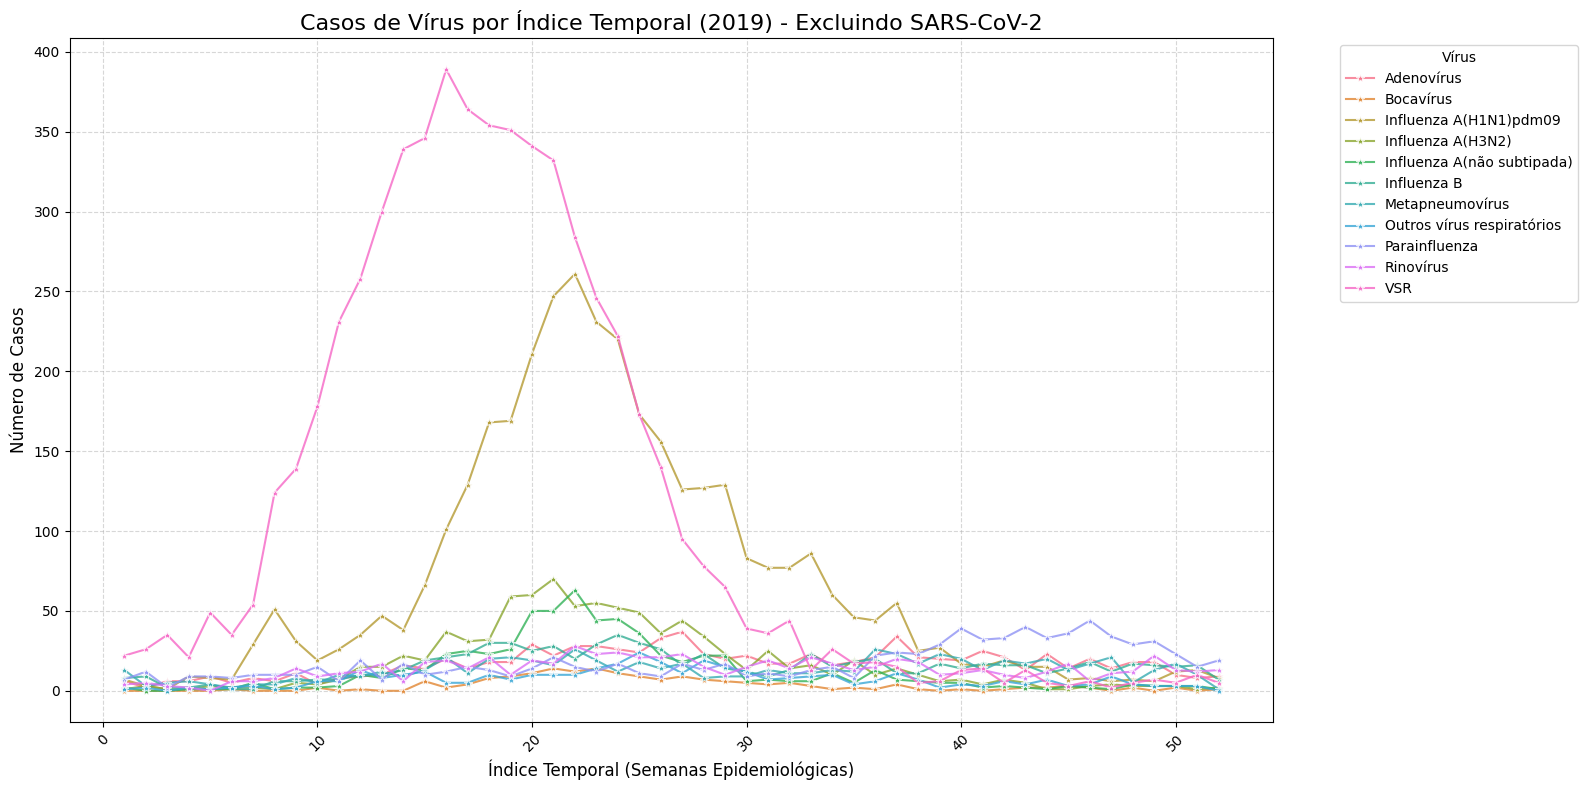

In [14]:
ano = 2019
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

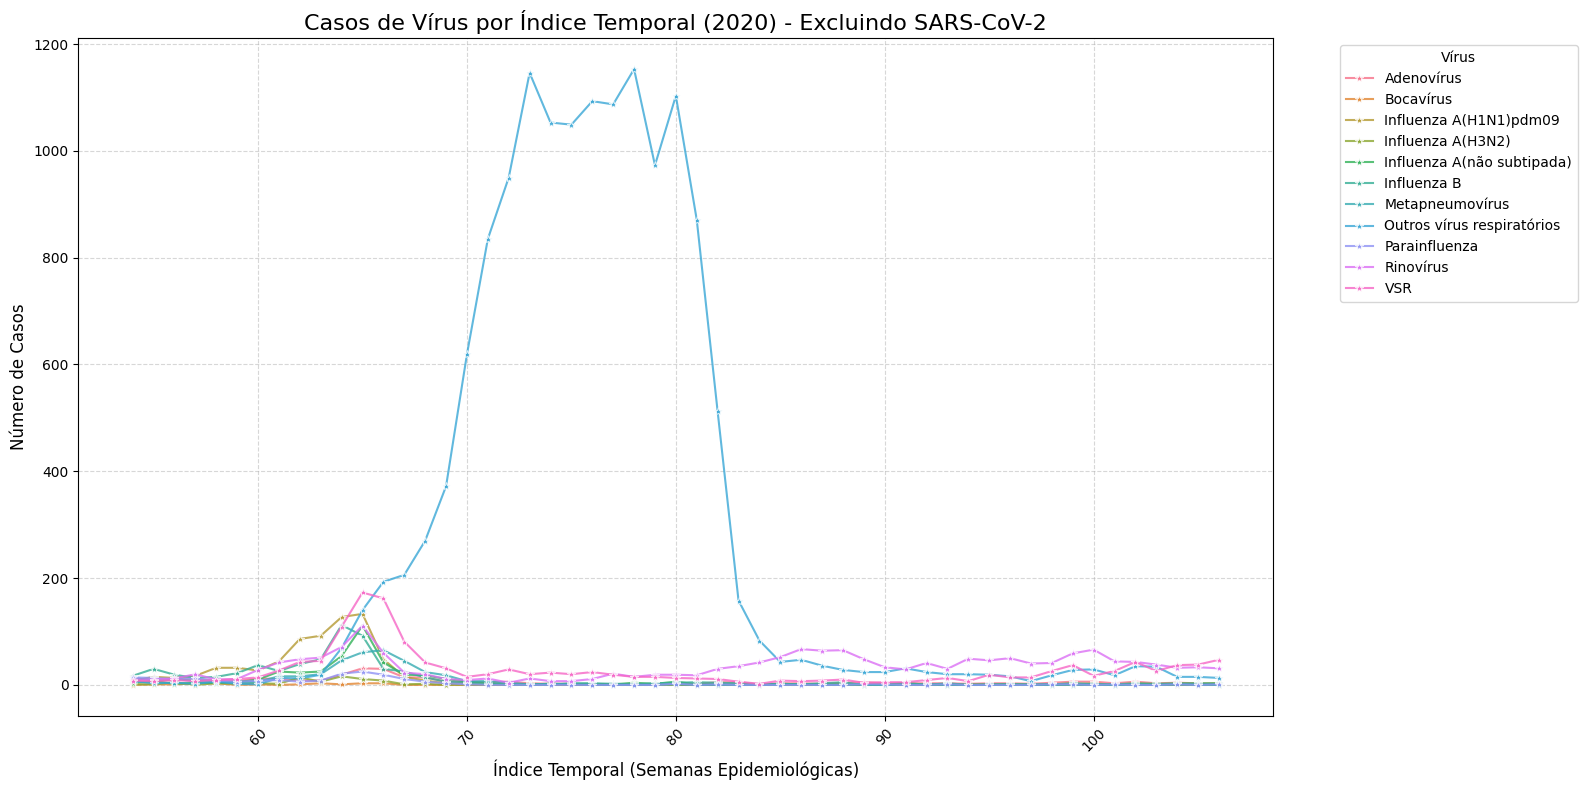

In [15]:
ano = 2020
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

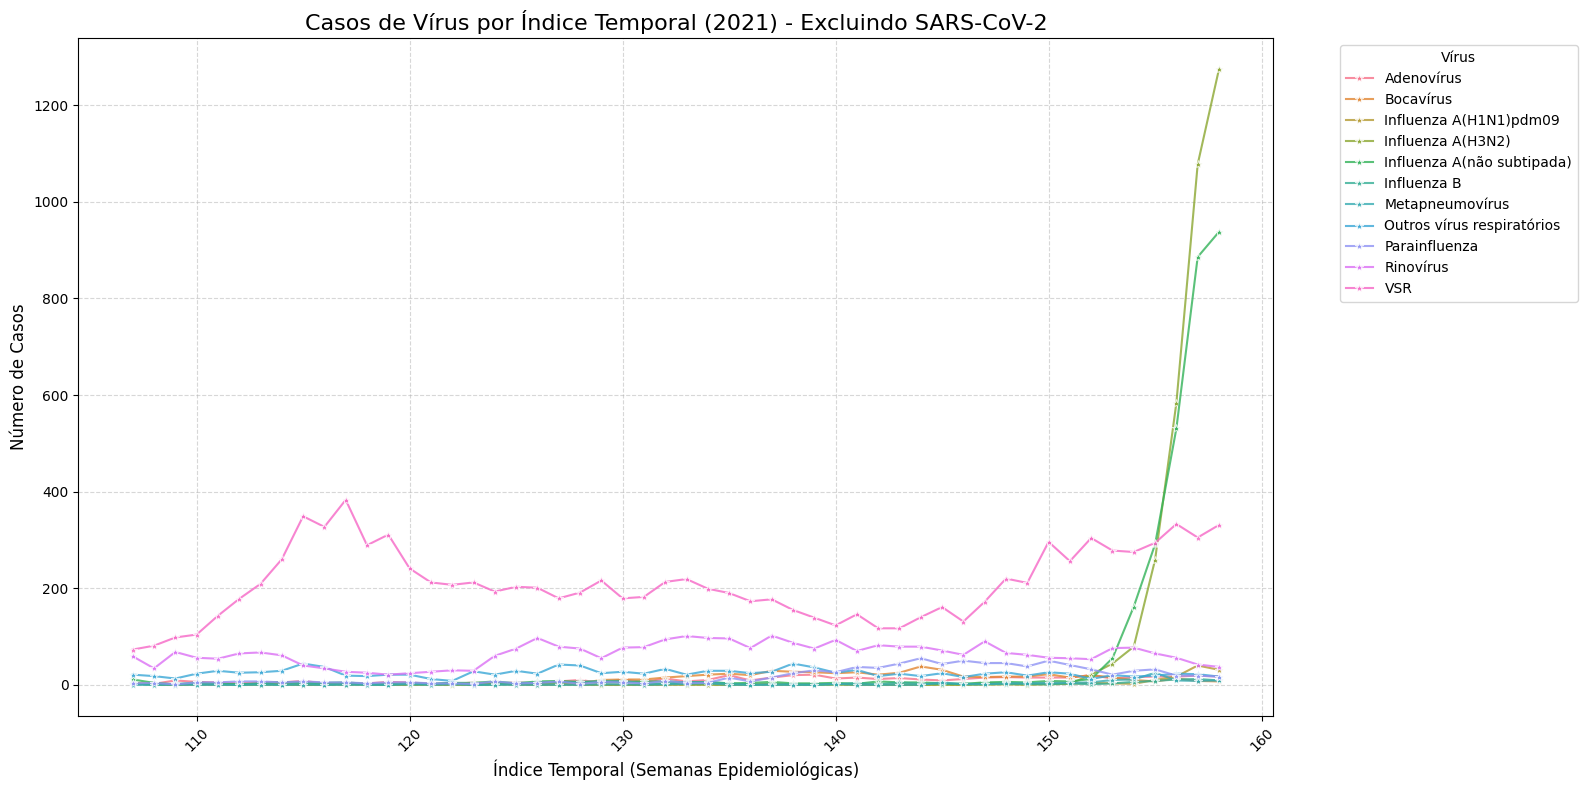

In [16]:
ano = 2021
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

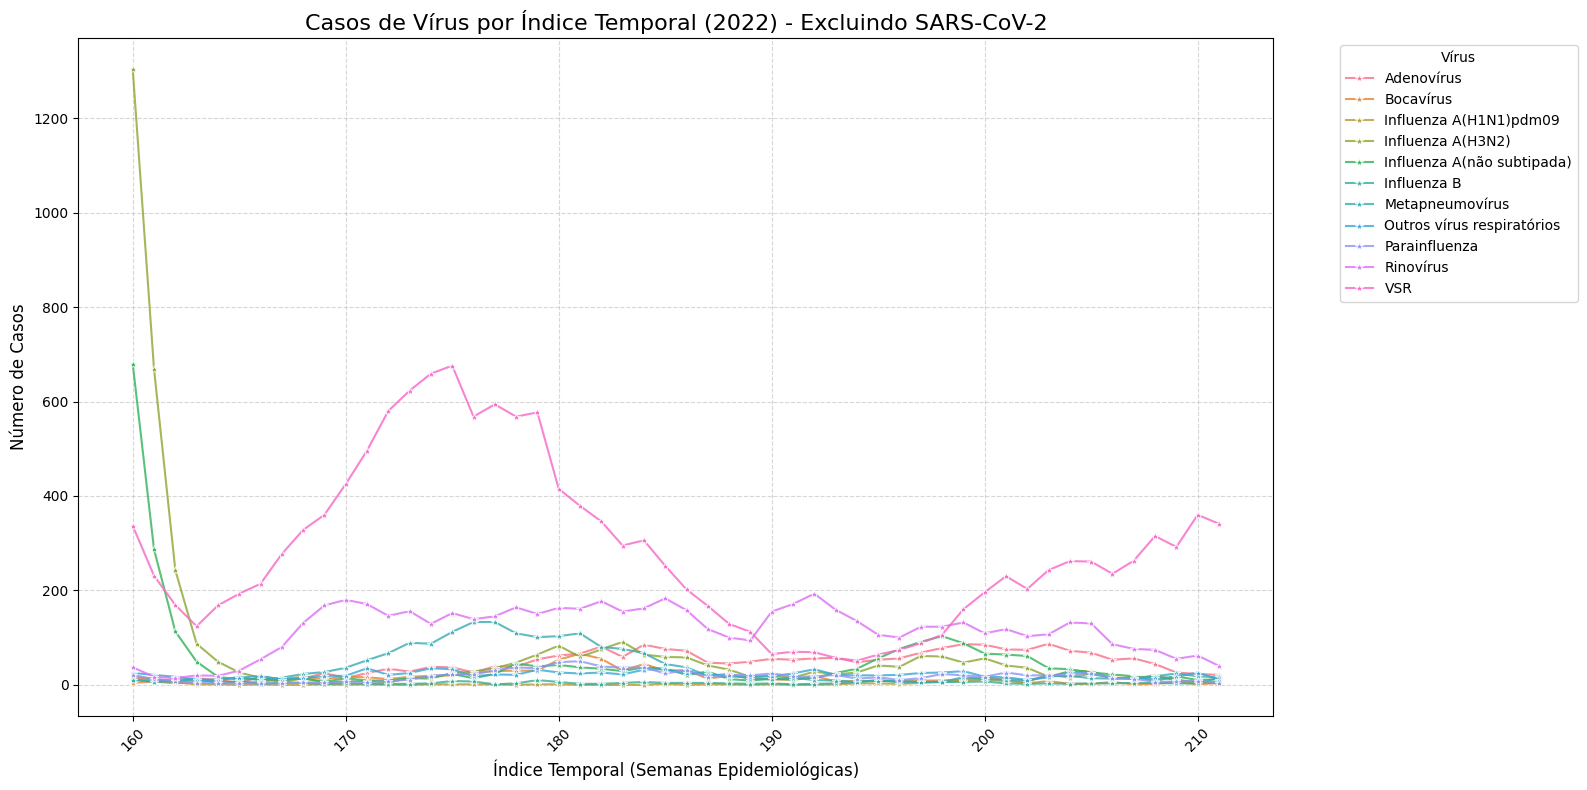

In [17]:
ano = 2022
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

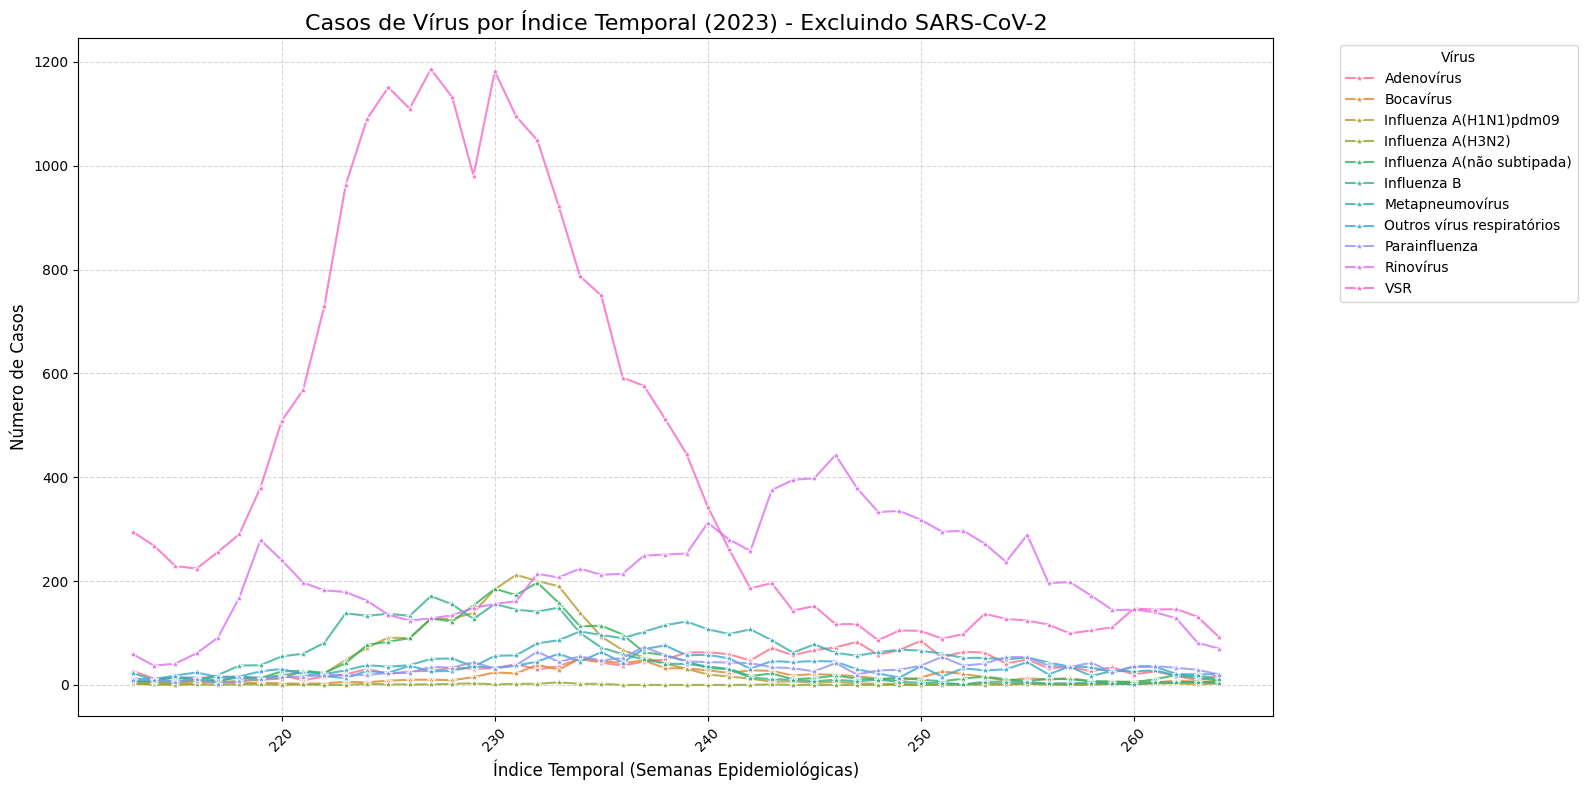

In [18]:
ano = 2023
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

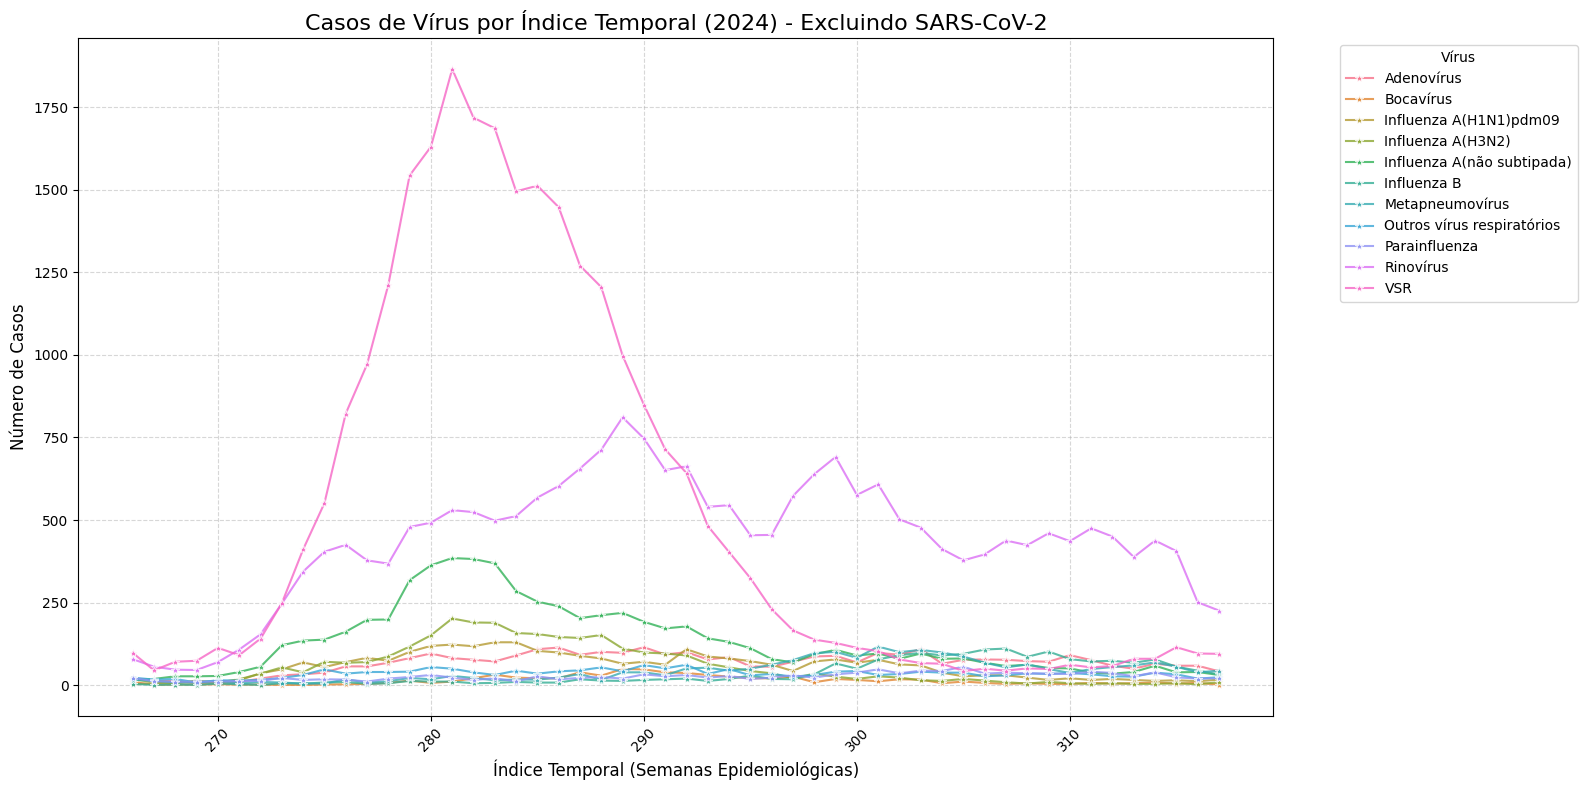

In [19]:
ano = 2024
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

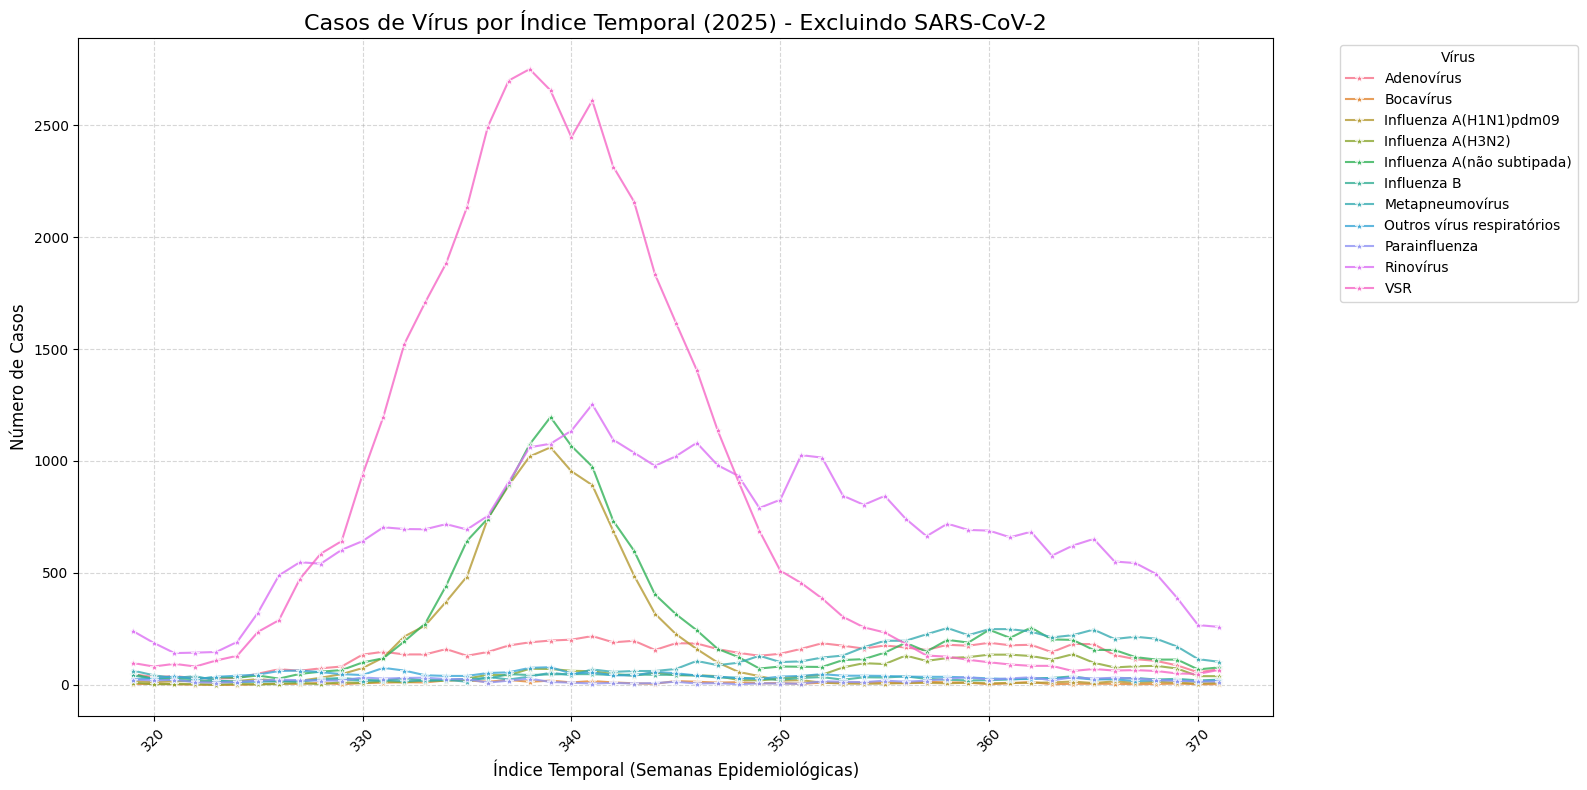

In [20]:
ano = 2025
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

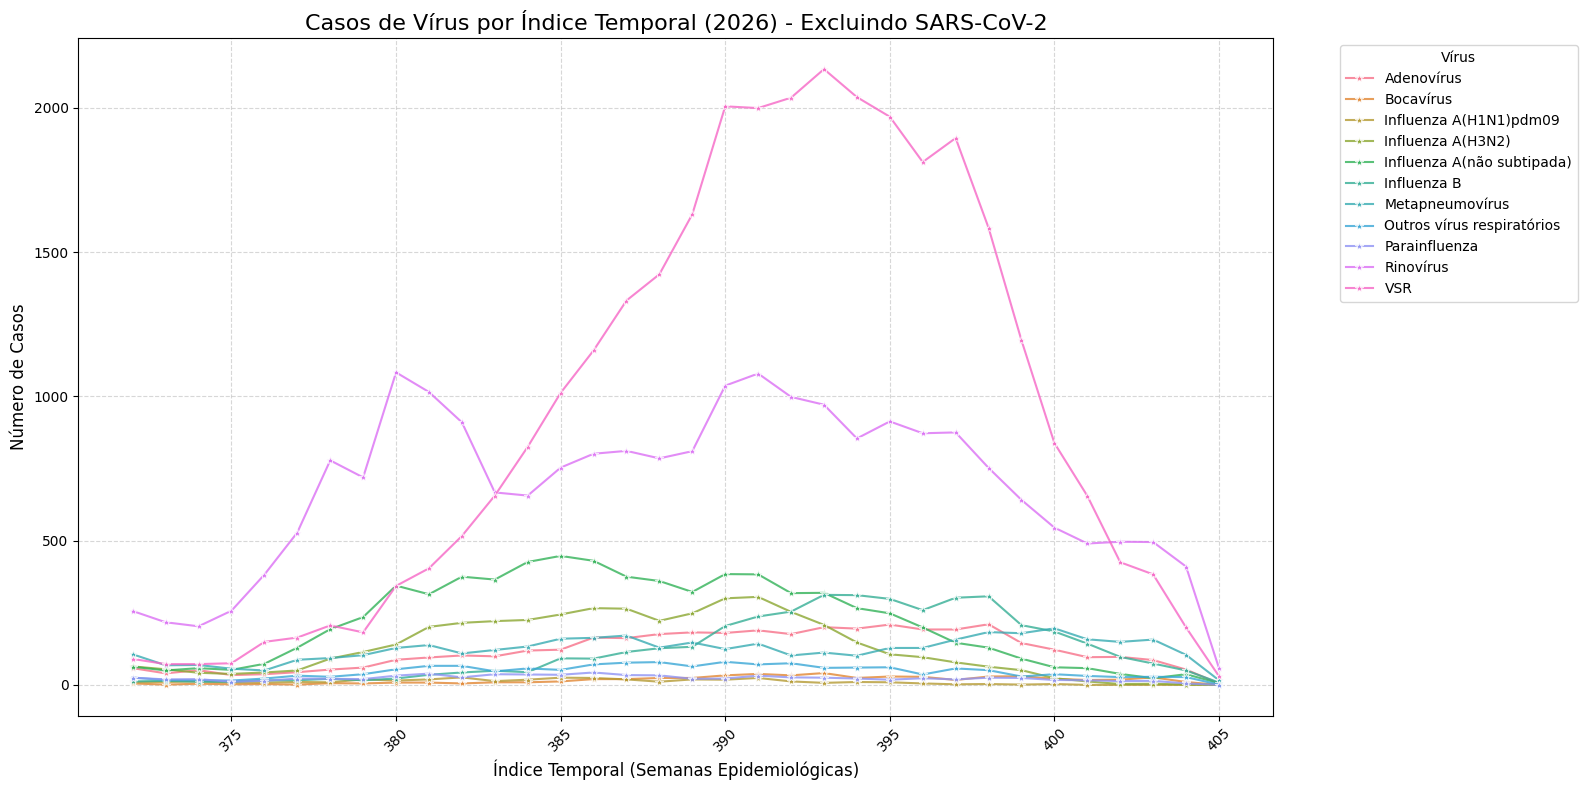

In [21]:
ano = 2026
df_filtered = df[(df['ano'] == ano) & (df['virus'] != "SARS-CoV-2") ]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_filtered, x='indice_temporal', y='casos', hue='virus', marker='*', alpha=0.8)
plt.title(f'Casos de Vírus por Índice Temporal ({ano}) - Excluindo SARS-CoV-2', fontsize=16)
plt.xlabel('Índice Temporal (Semanas Epidemiológicas)', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vírus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Dataset 2 - Óbitos

In [22]:
# ============================================================
# 1. Endereço raw do arquivo no GitLab
# https://gitlab.com/cgcovid/dados-publicos
# ============================================================
# dados inicialmente baixados do gitlab em 03/10/2026 as 16:03
url = (
    "https://gitlab.com/cgcovid/dados-publicos/-/raw/main/"
    "S%C3%A9ries%20hist%C3%B3ricas/Srag/Brasil/"
    "serie_historica_obitos.html"
)


# ============================================================
# 2. Download do arquivo HTML
# ============================================================

with urlopen(url) as resposta:
    html = resposta.read().decode("utf-8")


# ============================================================
# 3. Localização do JSON utilizado pelo Plotly
# ============================================================

padrao = re.compile(
    r'<script[^>]*type=["\']application/json["\'][^>]*>'
    r'(.*?)'
    r'</script>',
    flags=re.DOTALL
)

blocos_json = padrao.findall(html)

if not blocos_json:
    raise ValueError(
        "Nenhum bloco JSON foi encontrado no arquivo HTML."
    )


# ============================================================
# 4. Identificação do bloco que contém os dados do gráfico
# ============================================================

dados_plotly = None

for bloco in blocos_json:
    objeto = json.loads(bloco)

    if (
        isinstance(objeto, dict)
        and "x" in objeto
        and "data" in objeto["x"]
    ):
        dados_plotly = objeto["x"]["data"]
        break

if dados_plotly is None:
    raise ValueError(
        "O JSON foi encontrado, mas os dados do Plotly não foram localizados."
    )


# ============================================================
# 5. Transformação dos dados em registros tabulares
# ============================================================

registros = []

for serie in dados_plotly:

    nome_virus = serie["name"]
    indices_temporais = serie["x"]
    numero_casos = serie["y"]

    for indice, casos in zip(indices_temporais, numero_casos):

        registros.append({
            "indice_temporal": indice,
            "virus": nome_virus,
            "casos": casos
        })


# ============================================================
# 6. Criação do DataFrame
# ============================================================

df_obitos = pd.DataFrame(registros)


# ============================================================
# 7. Conversão dos tipos
# ============================================================

df_obitos["indice_temporal"] = pd.to_numeric(
    df_obitos["indice_temporal"],
    errors="coerce"
).astype("Int64")

df_obitos["casos"] = pd.to_numeric(
    df_obitos["casos"],
    errors="coerce"
)


# ============================================================
# 8. Recuperação do ano e da semana epidemiológica
# ============================================================

df_obitos["ano"] = (
    2019 + (df_obitos["indice_temporal" ] - 1) // 53
).astype("Int64")

df_obitos["semana"] = (
    1 + (df_obitos["indice_temporal" ] - 1) % 53
).astype("Int64")


# Identificação no formato ano-SE
df_obitos["ano_semana"] = (
    df_obitos["ano"].astype(str)
    + "-SE"
    + df_obitos["semana"].astype(str).str.zfill(2)
)


# ============================================================
# 9. Ordenação cronológica
# ============================================================

df_obitos = df_obitos.sort_values(
    ["indice_temporal", "virus"]
).reset_index(drop=True)


# ============================================================
# 10. Visualização inicial
# ============================================================

print(df_obitos.head())
print()
print(df_obitos.info())

   indice_temporal                       virus  casos   ano  semana ano_semana
0                1                  Adenovírus      2  2019       1  2019-SE01
1                1                   Bocavírus      0  2019       1  2019-SE01
2                1      Influenza A(H1N1)pdm09      3  2019       1  2019-SE01
3                1           Influenza A(H3N2)      0  2019       1  2019-SE01
4                1  Influenza A(não subtipada)      0  2019       1  2019-SE01

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   indice_temporal  4800 non-null   Int64 
 1   virus            4800 non-null   object
 2   casos            4800 non-null   int64 
 3   ano              4800 non-null   Int64 
 4   semana           4800 non-null   Int64 
 5   ano_semana       4800 non-null   object
dtypes: Int64(3), int64(1), object(2)
memory usage: 239.2+ 

In [31]:
df_obitos = df_obitos.rename(columns={'casos': 'obitos'})
display(df_obitos.head())

,indice_temporal,virus,obitos,ano,semana,ano_semana
0,1,Adenovírus,2,2019,1,2019-SE01
1,1,Bocavírus,0,2019,1,2019-SE01
2,1,Influenza A(H1N1)pdm09,3,2019,1,2019-SE01
3,1,Influenza A(H3N2),0,2019,1,2019-SE01
4,1,Influenza A(não subtipada),0,2019,1,2019-SE01


#### Série histórica Total

Casos e óbitos de 2019 a 2026 por SRAG.

In [33]:
# Mesclar os DataFrames com base nas chaves temporais e no vírus
df_srag_sh_casos_obitos = pd.merge(
    df,
    df_obitos[['indice_temporal', 'virus', 'obitos']],
    on=['indice_temporal', 'virus'],
    how='outer'
)

# Reordenar as colunas para posicionar 'obitos' logo à direita de 'casos'
colunas_ordenadas = [
    'indice_temporal',
    'virus',
    'casos',
    'obitos',
    'ano',
    'semana',
    'ano_semana'
]

df_srag_sh_casos_obitos = df_srag_sh_casos_obitos[colunas_ordenadas]

# Exibir as primeiras linhas para validação
display(df_srag_sh_casos_obitos.head())

,indice_temporal,virus,casos,obitos,ano,semana,ano_semana
0,1,Adenovírus,6,2,2019,1,2019-SE01
1,1,Bocavírus,0,0,2019,1,2019-SE01
2,1,Influenza A(H1N1)pdm09,7,3,2019,1,2019-SE01
3,1,Influenza A(H3N2),1,0,2019,1,2019-SE01
4,1,Influenza A(não subtipada),2,0,2019,1,2019-SE01


In [34]:
df.to_csv('df_srag_sh_casos_obitos.csv', index=False)